# Model 1

In [1]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
import torch.nn.functional as F
import numpy as np

/SASTRA-NEW-CLUSTER/users/baari/miniconda3/envs/research_credits/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
MAX_LEN = 128
BATCH_SIZE = 1024
HIDDEN_DIM = 100
NUM_FILTERS = 100
DROPOUT = 0.5
LEARNING_RATE = 1.6e-4
NUM_EPOCHS = 100
NUM_CLASSES = 3
EMBEDDING_DIM = 100

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arunavakrchakraborty/covid19-twitter-dataset")

print("Path to dataset files:", path)

Path to dataset files: /SASTRA-NEW-CLUSTER/users/baari/.cache/kagglehub/datasets/arunavakrchakraborty/covid19-twitter-dataset/versions/2


In [5]:
!ls $path

'Covid-19 Twitter Dataset (Apr-Jun 2020).csv'
'Covid-19 Twitter Dataset (Apr-Jun 2021).csv'
'Covid-19 Twitter Dataset (Aug-Sep 2020).csv'


In [6]:
df = pd.read_csv(path + '/Covid-19 Twitter Dataset (Apr-Jun 2020).csv')
df.head()

,id,created_at,source,original_text,lang,favorite_count,retweet_count,original_author,hashtags,user_mentions,place,clean_tweet,compound,neg,neu,pos,sentiment
0,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @GlblCtzn: .@priyankachopra is calling on l...,en,0.0,31.0,RJIshak,NaN,"GlblCtzn, priyankachopra",Jakarta Capital Region,call leader help protect refuge covid19 provid...,0.8176,0.0,0.452,0.548,pos
1,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @OGSG_Official: OGUN STATE SUPPORT FOR CBN-...,en,0.0,61.0,makinwaoluwole,NaN,OGSG_Official,Nigeria,ogun state support cbn nirsal covid19 target c...,0.6486,0.0,0.602,0.398,pos
2,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @AdvoBarryRoux: These 5 police officials ba...,en,0.0,1.0,TembeAmu,NaN,AdvoBarryRoux,NaN,polic offici base namahadi polic station busi ...,0.2732,0.0,0.851,0.149,pos
3,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @MobilePunch: COVID-19: Oyo discharges two ...,en,0.0,0.0,ilyasrabiu,NaN,MobilePunch,"Lagos, Nigeria",covid19 oyo discharg two patient,0.0000,0.0,1.000,0.000,neu
4,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",My Condolences to the Family of those who did ...,en,0.0,13869.0,bucketeconomist,Covid_19,NaN,NaN,condol famili surviv,0.0000,0.0,1.000,0.000,neu


In [7]:
#df = df.rename(columns={'2401': 'Tweet ID', 'Positive': 'Sentiment','im getting on borderlands and i will murder you all ,':'Clean_Tweet'})

In [8]:
df=df[['clean_tweet','sentiment']]
df.head()

,clean_tweet,sentiment
0,call leader help protect refuge covid19 provid...,pos
1,ogun state support cbn nirsal covid19 target c...,pos
2,polic offici base namahadi polic station busi ...,pos
3,covid19 oyo discharg two patient,neu
4,condol famili surviv,neu


In [9]:
df.isna().sum()

clean_tweet    484
sentiment        0
dtype: int64

In [10]:
df=df.dropna()
df.isna().sum()

clean_tweet    0
sentiment      0
dtype: int64

In [11]:
df['sentiment'].value_counts()

sentiment
neu    57102
pos    46125
neg    40192
Name: count, dtype: int64

In [12]:
def sentiment_to_numeric(sentiment):
  if sentiment == 'pos':
    return 2
  elif sentiment == 'neg':
    return 0
  elif sentiment == 'neu':
    return 1
  else:
      return 3

df['sentiment_numeric'] = df['sentiment'].apply(sentiment_to_numeric)

In [13]:
df.head()

,clean_tweet,sentiment,sentiment_numeric
0,call leader help protect refuge covid19 provid...,pos,2
1,ogun state support cbn nirsal covid19 target c...,pos,2
2,polic offici base namahadi polic station busi ...,pos,2
3,covid19 oyo discharg two patient,neu,1
4,condol famili surviv,neu,1


In [14]:
x=df.drop(columns=['sentiment_numeric'])
y=df['sentiment_numeric']
# Train-validation split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [26]:
# BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)['clean_tweet'].tolist() # Reset index and convert to list
        self.labels = labels.reset_index(drop=True).tolist() # Reset index and convert to list
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx]) # Now idx is the ordinal position
        label = self.labels[idx] # Now idx is the ordinal position

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = TwitterDataset(x_train, y_train, tokenizer, MAX_LEN)
val_dataset = TwitterDataset(x_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [27]:
class BERT_CNN_BiLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=768, out_channels=NUM_FILTERS, kernel_size=k)
            for k in [2, 3, 4]
        ])
        self.bilstm = nn.LSTM(
            input_size=768,
            hidden_size=HIDDEN_DIM,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(NUM_FILTERS * 3 + HIDDEN_DIM * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        # BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sequence_output = outputs.last_hidden_state

        # CNN branch
        cnn_input = sequence_output.permute(0, 2, 1)
        cnn_features = []
        for conv in self.convs:
            conv_out = conv(cnn_input)
            conv_out = F.relu(conv_out)
            pooled = F.max_pool1d(conv_out, conv_out.shape[2]).squeeze(2)
            cnn_features.append(pooled)
        cnn_features = torch.cat(cnn_features, dim=1)

        # BiLSTM branch
        lstm_out, (hidden, cell) = self.bilstm(sequence_output)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))

        # Combine features
        combined = torch.cat((cnn_features, hidden), dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)

model = BERT_CNN_BiLSTM(NUM_CLASSES).to(device)

In [28]:
# Optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

In [29]:
# Initialize lists to store losses for each epoch
training_losses = []
validation_losses = []

early_stop_patience = 3  # number of epochs to wait without improvement
best_val_loss = float('inf')
epochs_without_improvement = 0

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])

print("Starting training on device:", device)
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} - Training Started")
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 30 == 0:
            print(f" Training - Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} - Average Training Loss: {avg_train_loss:.4f}")

    # Validation
    print(f"Epoch {epoch+1} - Starting Validation")
    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_idx + 1) % 10 == 0:
                print(f" Validation - Batch {batch_idx+1}/{len(val_loader)} | Loss: {loss.item():.4f}")

    avg_val_loss = val_loss / len(val_loader)
    validation_losses.append(avg_val_loss)
    accuracy = correct / total

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Accuracy: {accuracy:.4f}\n")

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0  # reset counter
    else:
        epochs_without_improvement += 1
        print(f"No improvement in validation loss for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stop_patience:
        print("Early stopping: validation loss did not improve for", early_stop_patience, "consecutive epochs.")
        break

Using 8 GPUs!
Starting training on device: cuda

Epoch 1/100 - Training Started
 Training - Batch 30/113 | Loss: 0.3263
 Training - Batch 60/113 | Loss: 0.1380
 Training - Batch 90/113 | Loss: 0.0756
Epoch 1 - Average Training Loss: 0.3037
Epoch 1 - Starting Validation
 Validation - Batch 10/29 | Loss: 0.1020
 Validation - Batch 20/29 | Loss: 0.0656
Epoch 1/100 - Train Loss: 0.3037 | Val Loss: 0.0852
Epoch 1/100 - Accuracy: 0.9760


Epoch 2/100 - Training Started
 Training - Batch 30/113 | Loss: 0.0595
 Training - Batch 60/113 | Loss: 0.0535
 Training - Batch 90/113 | Loss: 0.0342
Epoch 2 - Average Training Loss: 0.0581
Epoch 2 - Starting Validation
 Validation - Batch 10/29 | Loss: 0.0634
 Validation - Batch 20/29 | Loss: 0.0492
Epoch 2/100 - Train Loss: 0.0581 | Val Loss: 0.0491
Epoch 2/100 - Accuracy: 0.9858


Epoch 3/100 - Training Started
 Training - Batch 30/113 | Loss: 0.0409
 Training - Batch 60/113 | Loss: 0.0316
 Training - Batch 90/113 | Loss: 0.0297
Epoch 3 - Average Traini

In [30]:
print("Training complete. Saving model...")
torch.save(model.state_dict(), 'bert_cnn_bilstm_model.pth')
print("Model saved to 'bert_cnn_bilstm_model.pth'")

Training complete. Saving model...
Model saved to 'bert_cnn_bilstm_model.pth'


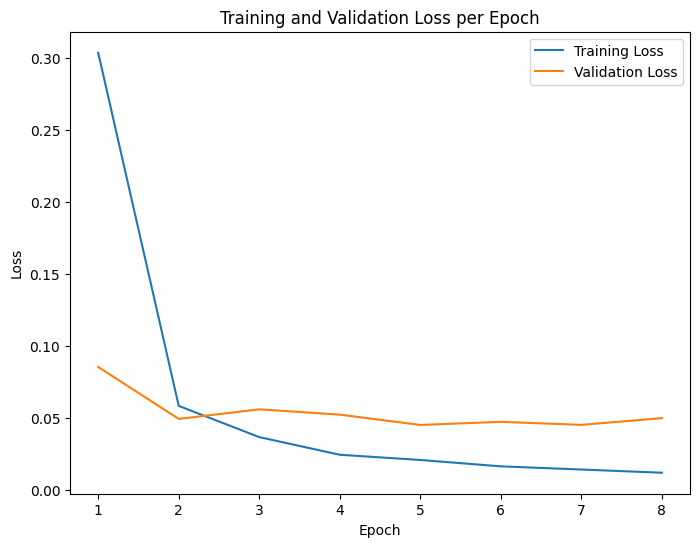

In [31]:
# Plot training and validation losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
epochs = range(1, len(training_losses) + 1)
plt.plot(epochs, training_losses, label='Training Loss')
plt.plot(epochs, validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [33]:
acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)

Accuracy: 0.9859977068204718


In [34]:
print("Confusion Matrix:")
confusion_matrix(all_labels, all_preds)

Confusion Matrix:


array([[ 7977,    15,    31],
       [   68, 11250,    36],
       [  229,    24,  9151]])

In [35]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9641    0.9943    0.9790      8023
           1     0.9965    0.9908    0.9937     11354
           2     0.9927    0.9731    0.9828      9404

    accuracy                         0.9860     28781
   macro avg     0.9845    0.9861    0.9852     28781
weighted avg     0.9863    0.9860    0.9860     28781



 # Model 2

In [36]:
!pip install nltk

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /SASTRA-NEW-
[nltk_data]     CLUSTER/users/baari/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /SASTRA-NEW-
[nltk_data]     CLUSTER/users/baari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /SASTRA-NEW-
[nltk_data]     CLUSTER/users/baari/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
#!wget http://nlp.stanford.edu/data/glove.6B.zip
#!unzip glove.6B.zip

In [16]:
# Load GloVe embeddings
def load_glove_embeddings(glove_file_path):
    embeddings_index = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_file_path = 'glove.6B.100d.txt'
embeddings_index = load_glove_embeddings(glove_file_path)

# Preprocess text data
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return tokens

# Creating vocabulary for your dataset
all_training_texts = pd.concat([x_train['clean_tweet'], x_test['clean_tweet']])
vocabulary = {}
word_index = 1 # start from 1, 0 will be reserved for padding
for text in all_training_texts:
    tokens = preprocess_text(str(text))
    for token in tokens:
        if token not in vocabulary:
            vocabulary[token] = word_index
            word_index += 1

def create_embedding_matrix(vocabulary, embeddings_index, embedding_dim):
    num_words = len(vocabulary) + 1  # Add 1 for padding token
    embedding_matrix = np.zeros((num_words, embedding_dim))
    for word, i in vocabulary.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    return embedding_matrix

# Create embedding matrix
embedding_matrix = create_embedding_matrix(vocabulary, embeddings_index, EMBEDDING_DIM)

# Create dataset class
class TwitterDataset(Dataset):
    def __init__(self, texts, labels, vocabulary, max_len):
        self.texts = texts.reset_index(drop=True)['clean_tweet'].tolist()
        self.labels = labels.reset_index(drop=True).tolist()
        self.vocabulary = vocabulary
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        tokens = preprocess_text(text)
        input_ids = [self.vocabulary.get(token, 0) for token in tokens]
        input_ids = input_ids[:self.max_len] + [0] * (self.max_len - len(input_ids))

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.ones(self.max_len, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = TwitterDataset(x_train, y_train, vocabulary, MAX_LEN)
val_dataset = TwitterDataset(x_test, y_test, vocabulary, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [17]:
import json

# Save the GloVe vocabulary
with open('glove_vocabulary.json', 'w') as f:
    json.dump(vocabulary, f)
print("GloVe vocabulary saved to 'glove_vocabulary.json'")

GloVe vocabulary saved to 'glove_vocabulary.json'


In [18]:
# Model architecture
class GloVe_CNN_BiLSTM(nn.Module):
    def __init__(self, embedding_matrix, num_classes):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float))
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_matrix.shape[1], out_channels=NUM_FILTERS, kernel_size=k)
            for k in [2, 3, 4]
        ])
        self.bilstm = nn.LSTM(
            input_size=embedding_matrix.shape[1],
            hidden_size=HIDDEN_DIM,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(NUM_FILTERS * 3 + HIDDEN_DIM * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        # CNN branch
        cnn_input = embedded.permute(0, 2, 1)
        cnn_features = []
        for conv in self.convs:
            conv_out = conv(cnn_input)
            conv_out = F.relu(conv_out)
            pooled = F.max_pool1d(conv_out, conv_out.shape[2]).squeeze(2)
            cnn_features.append(pooled)
        cnn_features = torch.cat(cnn_features, dim=1)

        # BiLSTM branch
        lstm_out, (hidden, cell) = self.bilstm(embedded)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))

        # Combine features
        combined = torch.cat((cnn_features, hidden), dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)

In [46]:
model = GloVe_CNN_BiLSTM(embedding_matrix, NUM_CLASSES).to(device)

In [47]:
# Optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

In [48]:
# Initialize lists to store losses for each epoch
training_losses = []
validation_losses = []

early_stop_patience = 3
best_val_loss = float('inf')
epochs_without_improvement = 0

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])

print("Starting training on device:", device)
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} - Training Started")
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        # attention_mask = batch['attention_mask'].to(device) # This line is not needed
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids) # Remove attention_mask here
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 30 == 0:
            print(f" Training - Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} - Average Training Loss: {avg_train_loss:.4f}")

    # Validation
    print(f"Epoch {epoch+1} - Starting Validation")
    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            input_ids = batch['input_ids'].to(device)
            # attention_mask = batch['attention_mask'].to(device) # This line is not needed
            labels = batch['label'].to(device)

            outputs = model(input_ids) # Remove attention_mask here
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_idx + 1) % 10 == 0:
                print(f" Validation - Batch {batch_idx+1}/{len(val_loader)} | Loss: {loss.item():.4f}")

    avg_val_loss = val_loss / len(val_loader)
    validation_losses.append(avg_val_loss)
    accuracy = correct / total

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Accuracy: {accuracy:.4f}\n")

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"No improvement in validation loss for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stop_patience:
        print("Early stopping: validation loss did not improve for", early_stop_patience, "consecutive epochs.")
        break

Using 8 GPUs!
Starting training on device: cuda

Epoch 1/100 - Training Started
 Training - Batch 30/113 | Loss: 1.0530
 Training - Batch 60/113 | Loss: 0.9986
 Training - Batch 90/113 | Loss: 0.9314
Epoch 1 - Average Training Loss: 0.9990
Epoch 1 - Starting Validation
 Validation - Batch 10/29 | Loss: 0.8678
 Validation - Batch 20/29 | Loss: 0.8725
Epoch 1/100 - Train Loss: 0.9990 | Val Loss: 0.8662
Epoch 1/100 - Accuracy: 0.6463


Epoch 2/100 - Training Started
 Training - Batch 30/113 | Loss: 0.8395
 Training - Batch 60/113 | Loss: 0.7679
 Training - Batch 90/113 | Loss: 0.7087
Epoch 2 - Average Training Loss: 0.7789
Epoch 2 - Starting Validation
 Validation - Batch 10/29 | Loss: 0.6921
 Validation - Batch 20/29 | Loss: 0.6948
Epoch 2/100 - Train Loss: 0.7789 | Val Loss: 0.6925
Epoch 2/100 - Accuracy: 0.7052


Epoch 3/100 - Training Started
 Training - Batch 30/113 | Loss: 0.6972
 Training - Batch 60/113 | Loss: 0.6120
 Training - Batch 90/113 | Loss: 0.6922
Epoch 3 - Average Traini

In [49]:
print("Training complete. Saving model...")
torch.save(model.state_dict(), 'glove_cnn_bilstm_model.pth')
print("Model saved to 'glove_cnn_bilstm_model.pth'")

Training complete. Saving model...
Model saved to 'glove_cnn_bilstm_model.pth'


In [ ]:
import numpy as np


# Convert lists to numpy arrays
training_losses_array = np.array(training_losses)
validation_losses_array = np.array(validation_losses)

# Save arrays to file
with open('GloveCNNBiLSTM_array.txt', 'w') as f:
    f.write("Training losses:\n")
    np.savetxt(f, training_losses_array, fmt='%.6f')
    f.write("\nValidation losses:\n")
    np.savetxt(f, validation_losses_array, fmt='%.6f')

print("Losses saved to GloveCNNBiLSTM_array.txt")

Losses saved to GloveCNNBiLSTM_array.txt


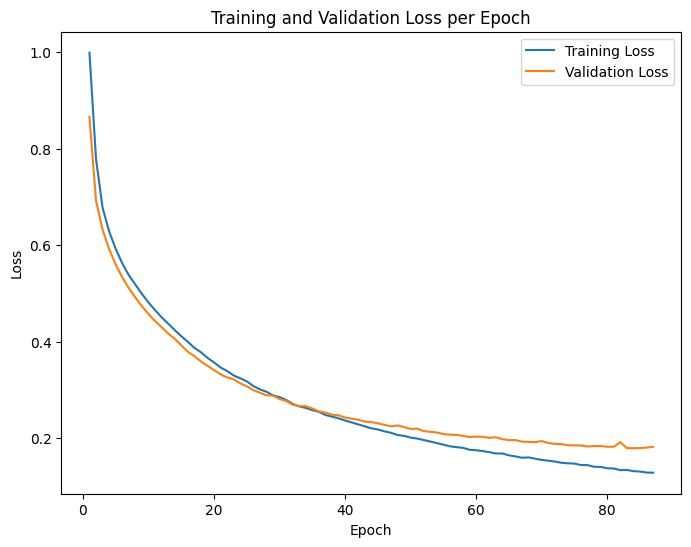

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
epochs = range(1, len(training_losses) + 1)
plt.plot(epochs, training_losses, label='Training Loss')
plt.plot(epochs, validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import numpy as np

# Ensure the model is in evaluation mode
model.eval()

# Initialize lists to store predictions and true labels
all_preds = []
all_labels = []

# Disable gradient calculations
with torch.no_grad():
    # Iterate over the validation data loader
    for batch in val_loader:
        # Move input IDs and labels to the configured device (GPU or CPU)
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        # Get model predictions
        # Note: The GloVe model forward pass only takes input_ids
        outputs = model(input_ids)

        # Get the index of the max log-probability (predicted class)
        _, preds = torch.max(outputs, 1)

        # Extend the lists with predictions and labels from the current batch
        # Move tensors to CPU and convert to numpy arrays before extending
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays for easier handling with sklearn metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions generated for GloVe_CNN_BiLSTM model.")
# The variables all_preds and all_labels are now populated and can be used in subsequent cells.

Predictions generated for GloVe_CNN_BiLSTM model.


In [57]:
acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)

Accuracy: 0.94246204092978


In [58]:
print("Confusion Matrix:")
confusion_matrix(all_labels, all_preds)

Confusion Matrix:


array([[ 7268,   363,   392],
       [  146, 11029,   179],
       [  238,   338,  8828]])

In [59]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9498    0.9059    0.9273      8023
           1     0.9402    0.9714    0.9556     11354
           2     0.9392    0.9387    0.9390      9404

    accuracy                         0.9425     28781
   macro avg     0.9431    0.9387    0.9406     28781
weighted avg     0.9426    0.9425    0.9423     28781



# Model 3

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [17]:
# vectorizer = CountVectorizer()

# svm_classifier = SVC()

# model = Pipeline([
#     ('vectorizer', vectorizer),
#     ('classifier', svm_classifier),
# ])

# model.fit(x_train['Clean_Tweet'], y_train)

# y_pred = model.predict(x_test['Clean_Tweet'])


# print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
# print(classification_report(y_test, y_pred))

In [18]:
# Install RAPIDS for CUDA 12.x
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

In [20]:


import cudf
import cuml
from cuml.svm import SVC
from cuml.feature_extraction.text import CountVectorizer

# Convert pandas dataframes to cudf
x_train_gpu = cudf.DataFrame.from_pandas(x_train[['clean_tweet']])
x_test_gpu = cudf.DataFrame.from_pandas(x_test[['clean_tweet']])
y_train_gpu = cudf.Series(y_train.values)

# Initialize GPU vectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(x_train_gpu['clean_tweet'])
X_test_vec = vectorizer.transform(x_test_gpu['clean_tweet'])




In [21]:

# Train SVM on GPU
# Added probability=True
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(X_train_vec, y_train_gpu)

# Predict
y_pred_gpu = svm_classifier.predict(X_test_vec)

[W] [13:15:07.816880] SVC with the linear kernel can be much faster using the specialized solver provided by LinearSVC. Consider switching to LinearSVC if tranining takes too long.


In [22]:
y_pred_gpu

array([1, 0, 0, ..., 1, 1, 2])

In [24]:
# SAVE MODEL
import joblib
joblib.dump(svm_classifier, 'svm_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("SVM model saved to 'svm_model.pkl'")

SVM model saved to 'svm_model.pkl'


In [ ]:
# # Create and save a compatible CPU version 
# try:
#     # Convert predictions to NumPy for CPU model training
#     X_train_cpu = x_train['clean_tweet'].values
#     y_train_cpu = y_train.values
    
#     # For CPU compatibility
#     from sklearn.feature_extraction.text import CountVectorizer as CPUVectorizer
#     from sklearn.svm import SVC as CPUSVC
    
#     cpu_vectorizer = CPUVectorizer()
#     X_train_vec_cpu = cpu_vectorizer.fit_transform(X_train_cpu)
    
#     # Added probability=True
#     cpu_classifier = CPUSVC(kernel='linear', probability=True)
#     cpu_classifier.fit(X_train_vec_cpu, y_train_cpu)
    
#     # Save CPU-compatible versions as fallbacks
#     joblib.dump(cpu_classifier, 'svm_model_cpu.pkl')
#     joblib.dump(cpu_vectorizer, 'vectorizer_cpu.pkl')
#     print("CPU fallback models saved successfully")
# except Exception as e:
#     print(f"Error creating CPU fallback models: {e}")


In [69]:
# Convert back to CPU for evaluation
import numpy as np

# Check if y_pred_gpu is already a numpy array or needs conversion
if hasattr(y_pred_gpu, 'to_numpy'):
    # If it's a cuDF Series/DataFrame
    y_pred = y_pred_gpu.to_numpy()
elif isinstance(y_pred_gpu, np.ndarray):
    # If it's already a numpy array
    y_pred = y_pred_gpu
elif hasattr(y_pred_gpu, 'get'):
    # If it's a CuPy array
    y_pred = y_pred_gpu.get()
else:
    # For any other type, try to convert to numpy array
    try:
        y_pred = np.array(y_pred_gpu)
    except TypeError:
        # If this also fails, try to convert to list first
        y_pred = np.array(list(y_pred_gpu))

y_test_array = y_test.values

# Evaluate
print(f"Accuracy: {accuracy_score(y_test_array, y_pred)}")
print(classification_report(y_test_array, y_pred))

Accuracy: 0.9826274278169626
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      8023
           1       0.99      0.99      0.99     11354
           2       0.97      0.98      0.98      9404

    accuracy                           0.98     28781
   macro avg       0.98      0.98      0.98     28781
weighted avg       0.98      0.98      0.98     28781

